# Orange County Residential & Multifamily Market Selection

**Goal:** Score and rank Orange County zip codes for residential rental / small multifamily investment attractiveness.
**Data sources:** Zillow ZHVI (price index), Zillow inventory & price cuts, Census ACS 2022 (renter rates, vacancy, rent burden, multifamily share).
**Output:** Ranked submarket table + interactive choropleth map.

Built for **Candice Blair — Niguel Point Properties / The Candice Blair Group** as a monthly market intelligence product for clients.

---

### Scoring framework

| Factor | Direction | Rationale |
|--------|-----------|----------|
| Renter % | Higher → better | Structural rental demand |
| Vacancy rate | Lower → better | Tight market, pricing power |
| Rent-to-income ratio | Lower → better | Room for rent growth before affordability ceiling |
| Rent burden >50% | Lower → better | Tenants near limit = cap on increases |
| Multifamily share | Higher → better | Established MF market, zoning permissive |
| 1yr price momentum | Higher → better | Market appreciation signal |
| Price cut rate (recent) | Lower → better | Seller power / low distress |
| Inventory change YoY | Lower → better | Supply tightness |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import folium
import json
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

DATA = Path('../data/raw')
OUT  = Path('../outputs')
OUT.mkdir(exist_ok=True)
(OUT / 'maps').mkdir(exist_ok=True)
(OUT / 'charts').mkdir(exist_ok=True)
(OUT / 'tables').mkdir(exist_ok=True)

## 1. Load and prepare data

In [2]:
# --- Zillow ZHVI (home value index) ---
zhvi = pd.read_csv(DATA / 'zillow_zhvi_zip.csv', dtype={'RegionName': str})
print(f'ZHVI: {zhvi.shape[0]} Orange County zip codes')

meta_cols = ['RegionID','SizeRank','RegionName','RegionType','StateName','State','City','Metro','CountyName']
date_cols = [c for c in zhvi.columns if c not in meta_cols]

recent_dates = sorted([c for c in date_cols if c >= '2020-01-01'])
zhvi_long = zhvi[meta_cols + recent_dates].copy()

# Compute 1yr and 3yr price change relative to the latest available month
latest = recent_dates[-1]
latest_dt = pd.Timestamp(latest)
one_yr_ago = [c for c in date_cols if pd.Timestamp(c) <= latest_dt - pd.DateOffset(years=1)][-1]
three_yr_ago = [c for c in date_cols if pd.Timestamp(c) <= latest_dt - pd.DateOffset(years=3)][-1]

zhvi_summary = zhvi[meta_cols + [three_yr_ago, one_yr_ago, latest]].copy()
zhvi_summary.columns = list(meta_cols) + ['price_3yr_ago', 'price_1yr_ago', 'price_latest']
zhvi_summary['price_chg_1yr_pct'] = (zhvi_summary['price_latest'] / zhvi_summary['price_1yr_ago'] - 1) * 100
zhvi_summary['price_chg_3yr_pct'] = (zhvi_summary['price_latest'] / zhvi_summary['price_3yr_ago'] - 1) * 100
zhvi_summary['zip_code'] = zhvi_summary['RegionName']

print(f'Latest ZHVI date: {latest}')
print(f'Median Orange County home value: ${zhvi_summary["price_latest"].median():,.0f}')

ZHVI: 86 Orange County zip codes
Latest ZHVI date: 2026-05-31
Median Orange County home value: $1,223,717


In [3]:
# --- Zillow inventory ---
inv = pd.read_csv(DATA / 'zillow_inventory_zip.csv', dtype={'RegionName': str})
inv_meta = ['RegionID','SizeRank','RegionName','RegionType','StateName','State','City','Metro','CountyName']
inv_dates = sorted([c for c in inv.columns if c not in inv_meta and c >= '2024-01-01'])
if inv_dates:
    inv_latest = inv_dates[-1]
    inv_6m_ago = inv_dates[max(0, len(inv_dates)-7)]
    inv_summary = inv[['RegionName', inv_6m_ago, inv_latest]].copy()
    inv_summary.columns = ['zip_code', 'inv_6m_ago', 'inv_latest']
    inv_summary['inv_chg_6m_pct'] = (inv_summary['inv_latest'] / inv_summary['inv_6m_ago'] - 1) * 100
    print(f'Inventory data: {len(inv_summary)} zips, latest {inv_latest}')
else:
    inv_summary = inv[['RegionName']].rename(columns={'RegionName':'zip_code'})
    inv_summary['inv_chg_6m_pct'] = np.nan
    print('No recent inventory dates found')

Inventory data: 84 zips, latest 2026-05-31


In [4]:
# --- Zillow price cuts ---
pc = pd.read_csv(DATA / 'zillow_price_cuts_zip.csv', dtype={'RegionName': str})
pc_meta = ['RegionID','SizeRank','RegionName','RegionType','StateName','State','City','Metro','CountyName']
pc_dates = sorted([c for c in pc.columns if c not in pc_meta and c >= '2024-01-01'])
if pc_dates:
    pc_latest = pc_dates[-1]
    pc_summary = pc[['RegionName', pc_latest]].copy()
    pc_summary.columns = ['zip_code', 'price_cut_rate']
    print(f'Price cuts data: {len(pc_summary)} zips, latest {pc_latest}')
else:
    pc_summary = pc[['RegionName']].rename(columns={'RegionName':'zip_code'})
    pc_summary['price_cut_rate'] = np.nan

Price cuts data: 76 zips, latest 2026-05-31


In [5]:
# --- Census ACS (zip-level) ---
oc_zips = set(zhvi_summary['zip_code'].dropna().tolist())

census = pd.read_csv(DATA / 'census_acs_zip.csv', dtype={'zip_code': str})
census_oc = census[census['zip_code'].isin(oc_zips)].copy()
print(f'Census: {len(census_oc)} Orange County zips matched')
census_oc[['zip_code','renter_pct','vacancy_rate','rent_to_income_ratio',
             'rent_burden_rate','multifamily_share','median_contract_rent',
             'median_household_income']].describe().round(3)

Census: 85 Orange County zips matched


,renter_pct,vacancy_rate,rent_to_income_ratio,rent_burden_rate,multifamily_share,median_contract_rent,median_household_income
count,85.000,85.000,85.000,85.000,85.000,8.500000e+01,85.000
mean,0.423,0.082,-496.940,0.271,0.205,-7.840958e+06,118221.235
std,0.163,0.117,4583.725,0.066,0.109,7.231039e+07,34425.887
min,0.098,0.016,-42259.622,0.000,0.003,-6.666667e+08,56928.000
25%,0.303,0.032,0.209,0.241,0.123,1.884000e+03,89654.000
50%,0.425,0.047,0.228,0.272,0.204,2.190000e+03,116618.000
75%,0.569,0.076,0.253,0.307,0.267,2.459000e+03,135822.000
max,0.721,0.656,0.416,0.465,0.608,3.461000e+03,206361.000


## 2. Build master zip-level dataset

In [6]:
# Merge all zip-level data
master = zhvi_summary[['zip_code','City','CountyName','Metro',
                         'price_latest','price_chg_1yr_pct','price_chg_3yr_pct']].copy()

master = master.merge(inv_summary[['zip_code','inv_chg_6m_pct']], on='zip_code', how='left')
master = master.merge(pc_summary[['zip_code','price_cut_rate']], on='zip_code', how='left')
master = master.merge(
    census_oc[['zip_code','renter_pct','vacancy_rate','rent_to_income_ratio',
                 'rent_burden_rate','multifamily_share','median_contract_rent',
                 'median_household_income','total_population','renter_occupied_units']],
    on='zip_code', how='left'
)

print(f'Master dataset: {len(master)} zip codes')
print(f'Census match rate: {master["renter_pct"].notna().mean():.1%}')
master.head()

Master dataset: 86 zip codes
Census match rate: 98.8%


,zip_code,City,CountyName,Metro,price_latest,price_chg_1yr_pct,price_chg_3yr_pct,inv_chg_6m_pct,price_cut_rate,renter_pct,vacancy_rate,rent_to_income_ratio,rent_burden_rate,multifamily_share,median_contract_rent,median_household_income,total_population,renter_occupied_units
0,92683,Westminster,Orange County,"Los Angeles-Long Beach-Anaheim, CA",1.103915e+06,2.642983,20.932565,38.888889,0.173333,0.475444,0.037267,0.278733,0.364575,0.165611,1865.0,80292.0,90630.0,13166.0
1,92804,Anaheim,Orange County,"Los Angeles-Long Beach-Anaheim, CA",9.442013e+05,1.178217,16.972293,9.375000,0.171429,0.577809,0.032173,0.277981,0.373011,0.370572,1757.0,75847.0,84700.0,14206.0
2,92704,Santa Ana,Orange County,"Los Angeles-Long Beach-Anaheim, CA",9.014573e+05,0.859329,17.094788,39.062500,0.191011,0.495911,0.032914,0.253909,0.216006,0.301550,1897.0,89654.0,80767.0,9884.0
3,92805,Anaheim,Orange County,"Los Angeles-Long Beach-Anaheim, CA",8.623436e+05,1.347568,15.001521,9.756098,0.266667,0.596357,0.077975,0.259194,0.267196,0.290270,1762.0,81576.0,73310.0,12474.0
4,90631,La Habra,Orange County,"Los Angeles-Long Beach-Anaheim, CA",9.426083e+05,0.482531,15.050015,25.000000,0.234783,0.399524,0.031002,0.214021,0.227288,0.241514,1748.0,98009.0,69064.0,8905.0


## 3. Compute composite investment score

In [7]:
def percentile_rank(series, invert=False):
    """Rank each value 0-100 by percentile. invert=True means lower is better."""
    filled = series.fillna(series.median())
    ranks = filled.rank(pct=True) * 100
    return (100 - ranks) if invert else ranks

scored = master.copy()

# Individual factor scores (all 0-100, higher = more attractive)
scored['s_renter_pct']       = percentile_rank(scored['renter_pct'])
scored['s_low_vacancy']      = percentile_rank(scored['vacancy_rate'], invert=True)
scored['s_affordability']    = percentile_rank(scored['rent_to_income_ratio'], invert=True)
scored['s_low_rent_burden']  = percentile_rank(scored['rent_burden_rate'], invert=True)
scored['s_mf_share']         = percentile_rank(scored['multifamily_share'])
scored['s_price_momentum']   = percentile_rank(scored['price_chg_1yr_pct'])
scored['s_low_price_cuts']   = percentile_rank(scored['price_cut_rate'], invert=True)
scored['s_tight_inventory']  = percentile_rank(scored['inv_chg_6m_pct'], invert=True)

# Weighted composite — emphasize structural demand and supply tightness
weights = {
    's_renter_pct':      0.20,
    's_low_vacancy':     0.15,
    's_affordability':   0.15,
    's_low_rent_burden': 0.10,
    's_mf_share':        0.15,
    's_price_momentum':  0.10,
    's_low_price_cuts':  0.10,
    's_tight_inventory': 0.05,
}

scored['investment_score'] = sum(
    scored[col] * w for col, w in weights.items()
)

scored = scored.sort_values('investment_score', ascending=False).reset_index(drop=True)
scored['rank'] = scored.index + 1

print('Top 15 zip codes by investment score:')
display_cols = ['rank','zip_code','City','investment_score',
                'renter_pct','vacancy_rate','price_chg_1yr_pct',
                'median_contract_rent','rent_to_income_ratio']
top15 = scored[display_cols].head(15).copy()
top15['renter_pct'] = top15['renter_pct'].map('{:.1%}'.format)
top15['vacancy_rate'] = top15['vacancy_rate'].map('{:.1%}'.format)
top15['price_chg_1yr_pct'] = top15['price_chg_1yr_pct'].map('{:+.1f}%'.format)
top15['median_contract_rent'] = top15['median_contract_rent'].map('${:,.0f}'.format)
top15['rent_to_income_ratio'] = top15['rent_to_income_ratio'].map('{:.2f}'.format)
top15['investment_score'] = top15['investment_score'].map('{:.1f}'.format)
top15

Top 15 zip codes by investment score:


,rank,zip_code,City,investment_score,renter_pct,vacancy_rate,price_chg_1yr_pct,median_contract_rent,rent_to_income_ratio
0,1,92661,Newport Beach,70.6,62.3%,62.1%,+12.7%,"$2,317",0.14
1,2,90621,Buena Park,70.3,63.4%,3.1%,+0.7%,"$1,793",0.24
2,3,92701,Santa Ana,69.7,69.4%,2.7%,+2.2%,"$1,471",0.27
3,4,92627,Costa Mesa,65.6,62.3%,4.3%,+6.3%,"$2,064",0.23
4,5,92707,Santa Ana,65.6,49.8%,3.5%,+1.8%,"$1,920",0.24
5,6,90720,Los Alamitos,64.1,35.4%,2.9%,+2.1%,"$2,211",0.20
6,7,92706,Santa Ana,63.9,47.3%,2.6%,+1.5%,"$1,617",0.21
7,8,92843,Garden Grove,63.4,51.5%,3.3%,+3.0%,"$1,734",0.25
8,9,92866,Orange,63.3,66.3%,6.8%,+2.0%,"$1,740",0.25
9,10,92648,Huntington Beach,63.1,53.2%,8.5%,+4.6%,"$2,120",0.22


## 4. Factor breakdown: what's driving the top markets

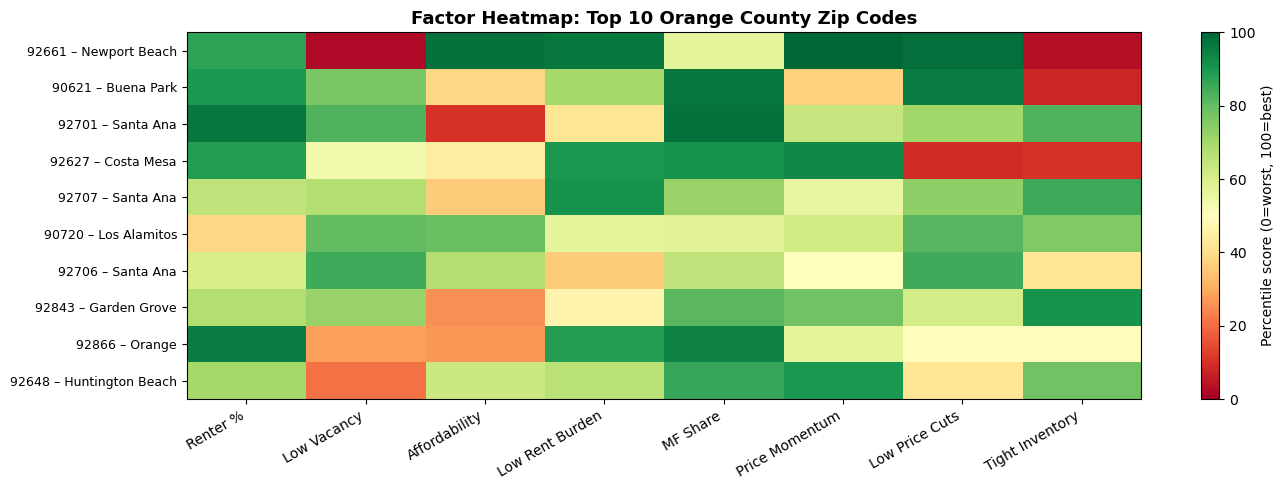

Saved factor heatmap


In [8]:
factor_cols = list(weights.keys())
factor_labels = [
    'Renter %', 'Low Vacancy', 'Affordability', 'Low Rent Burden',
    'MF Share', 'Price Momentum', 'Low Price Cuts', 'Tight Inventory'
]

top10 = scored.head(10).set_index('zip_code')[factor_cols]
top10.columns = factor_labels

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(top10.values, aspect='auto', cmap='RdYlGn', vmin=0, vmax=100)
ax.set_xticks(range(len(factor_labels)))
ax.set_xticklabels(factor_labels, rotation=30, ha='right', fontsize=10)
ax.set_yticks(range(len(top10)))
ax.set_yticklabels(
    [f"{z} – {scored[scored['zip_code']==z]['City'].values[0]}" for z in top10.index],
    fontsize=9
)
plt.colorbar(im, ax=ax, label='Percentile score (0=worst, 100=best)')
ax.set_title('Factor Heatmap: Top 10 Orange County Zip Codes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT / 'charts/factor_heatmap_top10.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved factor heatmap')

## 5. City-level summary

Orange County is a single county with 30+ incorporated cities and distinct submarkets — city is the
more useful rollup here than county (unlike the Bay Area, which spans nine counties).

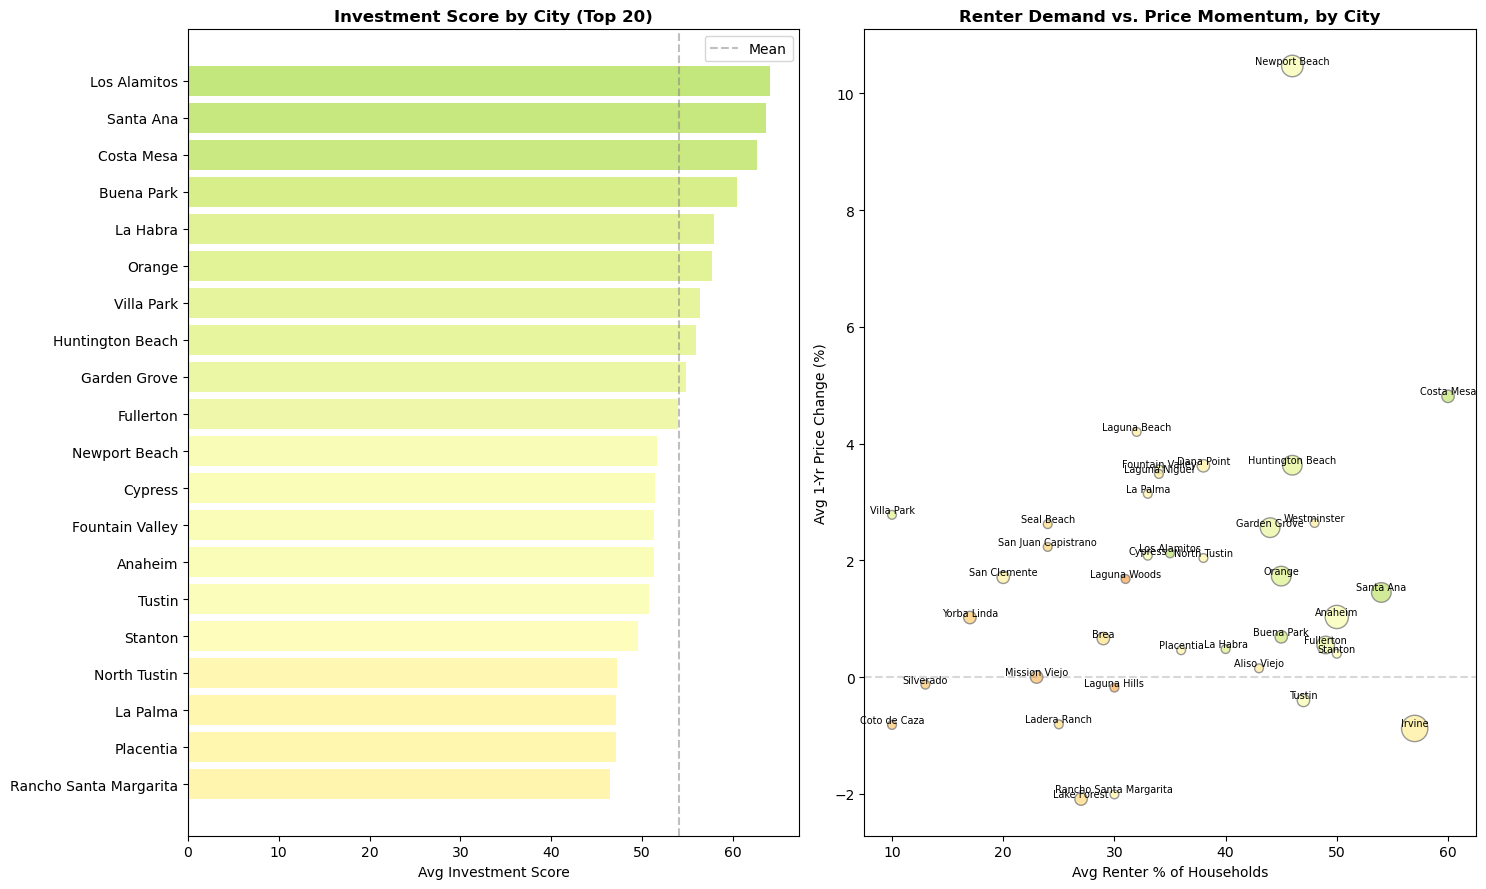

In [9]:
city_summary = scored.groupby('City').agg(
    zip_count=('zip_code','count'),
    avg_score=('investment_score','mean'),
    median_rent=('median_contract_rent','median'),
    avg_renter_pct=('renter_pct','mean'),
    avg_vacancy=('vacancy_rate','mean'),
    avg_price_chg_1yr=('price_chg_1yr_pct','mean'),
    avg_price_latest=('price_latest','mean'),
).sort_values('avg_score', ascending=False).round(2)

fig, axes = plt.subplots(1, 2, figsize=(15, 9))

top_cities = city_summary.head(20)
scores = top_cities['avg_score'].values
colors = cm.RdYlGn(scores / 100)

axes[0].barh(top_cities.index[::-1], scores[::-1], color=colors[::-1])
axes[0].set_xlabel('Avg Investment Score')
axes[0].set_title('Investment Score by City (Top 20)', fontweight='bold')
axes[0].axvline(scores.mean(), color='gray', linestyle='--', alpha=0.5, label='Mean')
axes[0].legend()

axes[1].scatter(
    city_summary['avg_renter_pct'] * 100,
    city_summary['avg_price_chg_1yr'],
    s=city_summary['zip_count'] * 40,
    c=city_summary['avg_score'], cmap='RdYlGn', vmin=0, vmax=100, alpha=0.8, edgecolors='gray'
)
for city, row in city_summary.iterrows():
    axes[1].annotate(city, (row['avg_renter_pct']*100, row['avg_price_chg_1yr']), fontsize=7, ha='center', va='bottom')
axes[1].set_xlabel('Avg Renter % of Households')
axes[1].set_ylabel('Avg 1-Yr Price Change (%)')
axes[1].set_title('Renter Demand vs. Price Momentum, by City', fontweight='bold')
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig(OUT / 'charts/city_summary.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Interactive choropleth map

In [10]:
# Zip boundaries: Census 2020 ZCTA cartographic boundary file, pre-filtered to
# Orange County zips using the official ZCTA-to-county relationship file
# (see data/raw/oc_zip_list.txt for methodology).
with open(DATA / 'oc_zips.geojson') as f:
    oc_geo = json.load(f)

zip_key = 'ZCTA5CE20'
print(f'Loaded {len(oc_geo["features"])} Orange County zip polygons')

m = folium.Map(location=[33.7, -117.8], zoom_start=10, tiles='CartoDB positron')

scored_for_map = scored[['zip_code','City','investment_score',
                          'renter_pct','vacancy_rate','price_chg_1yr_pct',
                          'median_contract_rent','price_latest']].copy()
scored_for_map = scored_for_map.dropna(subset=['investment_score'])

choropleth = folium.Choropleth(
    geo_data=oc_geo,
    name='Investment Score',
    data=scored_for_map,
    columns=['zip_code', 'investment_score'],
    key_on=f'feature.properties.{zip_key}',
    fill_color='RdYlGn',
    fill_opacity=0.7,
    line_opacity=0.3,
    legend_name='Residential Investment Score (0-100)',
    bins=8,
).add_to(m)

choropleth.geojson.add_child(
    folium.features.GeoJsonTooltip(fields=[zip_key], aliases=['ZIP:'], localize=True)
)

for _, row in scored_for_map.head(20).iterrows():
    matching = [f for f in oc_geo['features'] if f['properties'].get(zip_key) == row['zip_code']]
    if matching:
        coords = matching[0]['geometry']['coordinates']
        if matching[0]['geometry']['type'] == 'Polygon':
            lons = [c[0] for c in coords[0]]
            lats = [c[1] for c in coords[0]]
        else:
            lons = [c[0] for ring in coords[0] for c in ring]
            lats = [c[1] for ring in coords[0] for c in ring]
        lat, lon = np.mean(lats), np.mean(lons)

        popup_html = f"""
        <b>ZIP {row['zip_code']} – {row['City']}</b><br>
        Investment Score: <b>{row['investment_score']:.1f}</b><br>
        Renter %: {row['renter_pct']:.1%}<br>
        Vacancy: {row['vacancy_rate']:.1%}<br>
        Median Rent: ${row['median_contract_rent']:,.0f}/mo<br>
        1yr Price Chg: {row['price_chg_1yr_pct']:+.1f}%
        """
        folium.CircleMarker(
            location=[lat, lon],
            radius=6,
            color='darkgreen',
            fill=True,
            fill_opacity=0.8,
            popup=folium.Popup(popup_html, max_width=220),
            tooltip=f"#{scored_for_map[scored_for_map['zip_code']==row['zip_code']].index[0]+1} {row['zip_code']}"
        ).add_to(m)

folium.LayerControl().add_to(m)
map_path = OUT / 'maps/market_selection_map.html'
m.save(str(map_path))
print(f'Map saved to {map_path}')
m

Loaded 88 Orange County zip polygons
Map saved to ../outputs/maps/market_selection_map.html


## 7. Rent cap exposure (AB 1482)

Orange County cities generally do **not** have local rent control ordinances (unlike the Bay Area).
The relevant statewide framework is California's **Tenant Protection Act of 2019 (AB 1482)**, which caps
annual rent increases at 5% + local CPI (max 10%) for covered units.

**Key exemptions Candice's clients should know:**
- Single-family homes and condos **not owned by a corporation or REIT** (most of her SFR clients qualify)
- Buildings with a certificate of occupancy issued in the **last 15 years** (rolling exemption)
- Duplexes where the owner occupies one unit

This means most of Candice's small-portfolio SFR and duplex clients are largely **exempt** from AB 1482 rent
caps — a meaningfully different risk profile than the Bay Area's strict local ordinances covered in the
original SF analysis.

In [11]:
scored['ab1482_note'] = 'Most SFR/condo (non-corporate owner) exempt; multifamily 15yr+ subject to 5%+CPI cap'

print('Reminder: AB 1482 exemption status depends on entity type and building age — verify per property.')

Reminder: AB 1482 exemption status depends on entity type and building age — verify per property.


## 8. Candice's actual service area — where the value is

Two service-area lists, scraped directly from Candice's own sites (July 2026):
- **Niguel Point Properties** (property management) publishes a 14-city South OC service area.
- **The Candice Blair Group** (sales) publishes a narrower 9-city "featured cities" list, including
  "Canyon Areas" — resolved here to Coto de Caza, Rancho Santa Margarita, and Silverado, the
  unincorporated/canyon communities conventionally grouped under that label in South OC real
  estate marketing.

This section flags every zip code that falls in either list, and layers on three factors that
matter specifically for Candice's business but aren't in the composite investment score above —
because they're regulatory/qualitative, not something that belongs in a percentile ranking:

| Factor | Why it matters here |
|--------|---------------------|
| Short-term rental (STR) status | Candice personally owns an Airbnb, and several of her core cities (Laguna Niguel — her own HQ city — Irvine, Aliso Viejo, Lake Forest, Costa Mesa) **ban STRs outright** |
| Mello-Roos / CFD signal | South OC's master-planned communities (Ladera Ranch, Rancho Mission Viejo, Irvine's newer villages) carry some of the heaviest special-tax burdens in the county — directly cuts into net rental yield |
| Wildfire exposure | Canyon/WUI communities in her footprint (Coto de Caza, Silverado, Laguna Beach hillsides) face elevated insurance cost and availability risk |

**These are directional flags from manual research (see `data/reference/SOURCES.md`), not a live
feed — verify before advising a client.** Ordinances and CFD terms change; the wildfire flag in
particular is not a parcel-level lookup against CAL FIRE's actual GIS layer.

In [12]:
service_area = pd.read_csv('../data/reference/oc_service_area_factors.csv')
service_area = service_area.rename(columns={'city': 'City'})

scored = scored.merge(service_area, on='City', how='left')
scored['core_service_area'] = scored['in_pm_service_area'].eq('Yes') | scored['in_sales_featured_cities'].str.startswith('Yes', na=False)
scored['core_service_area'] = scored['core_service_area'].fillna(False)

n_service = scored['core_service_area'].sum()
print(f'{n_service} of {len(scored)} Orange County zip codes fall in Candice\'s core service area')

service_ranked = scored[scored['core_service_area']].sort_values('investment_score', ascending=False)
cols_show = ['rank','zip_code','City','investment_score','str_status','mello_roos_signal','wildfire_notes']
print('\nHer service area, ranked by investment score:')
service_ranked[cols_show]

39 of 86 Orange County zip codes fall in Candice's core service area

Her service area, ranked by investment score:


,rank,zip_code,City,investment_score,str_status,mello_roos_signal,wildfire_notes
0,1,92661,Newport Beach,70.639535,Permitted (cap),Low,Low-Moderate (Newport Coast/Crystal Cove footh...
3,4,92627,Costa Mesa,65.639535,Banned,Low,Low
9,10,92648,Huntington Beach,63.081395,Permitted (restricted),Low,Low
13,14,92626,Costa Mesa,59.651163,Banned,Low,Low
14,15,92672,San Clemente,59.505814,Permitted (caps + min. stay),Moderate (Talega district; some bonds maturing),Low-Moderate (some canyon edges)
18,19,92606,Irvine,58.750000,Banned,Heavy (many newer villages),Low-Moderate (eastern foothill villages near o...
22,23,90742,Huntington Beach,57.674419,Permitted (restricted),Low,Low
26,27,92663,Newport Beach,55.988372,Permitted (cap),Low,Low-Moderate (Newport Coast/Crystal Cove footh...
27,28,92647,Huntington Beach,55.639535,Permitted (restricted),Low,Low
30,31,92649,Huntington Beach,54.709302,Permitted (restricted),Low,Low


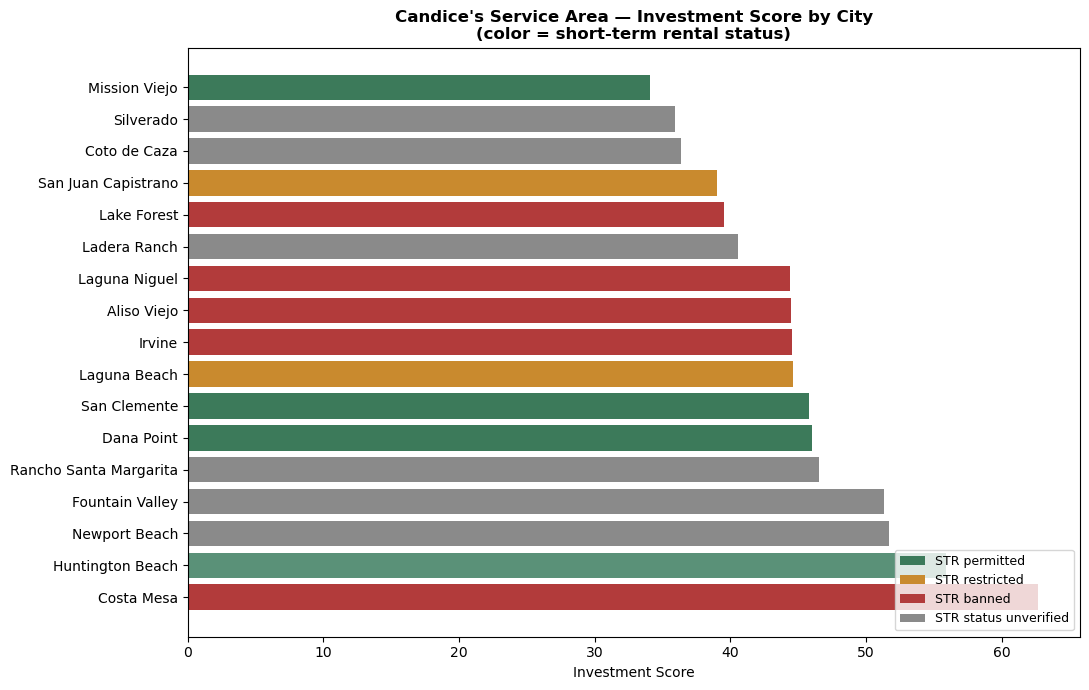

In [13]:
# Scorecard: investment score by city, colored by STR status — the single most useful
# at-a-glance view for evaluating her own buy-and-hold / Airbnb targets
city_service = service_ranked.groupby(['City','str_status'], as_index=False)['investment_score'].mean()
city_service = city_service.sort_values('investment_score', ascending=False)

str_colors = {
    'Banned': '#b23b3b',
    'Restricted': '#c98a2e',
    'Permitted (cap/waitlist)': '#3c7a5a',
    'Permitted (registration + 8% TOT)': '#3c7a5a',
    'Permitted (caps + min. stay)': '#3c7a5a',
    'Permitted (restricted)': '#5a9178',
    'Verify (unincorporated)': '#8a8a8a',
    'Verify': '#8a8a8a',
    'Verify (unincorporated/gated)': '#8a8a8a',
}
colors = [str_colors.get(s, '#8a8a8a') for s in city_service['str_status']]

fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(city_service['City'], city_service['investment_score'], color=colors)
ax.set_xlabel('Investment Score')
ax.set_title("Candice's Service Area — Investment Score by City\n(color = short-term rental status)", fontweight='bold')

from matplotlib.patches import Patch
legend_items = [
    Patch(facecolor='#3c7a5a', label='STR permitted'),
    Patch(facecolor='#c98a2e', label='STR restricted'),
    Patch(facecolor='#b23b3b', label='STR banned'),
    Patch(facecolor='#8a8a8a', label='STR status unverified'),
]
ax.legend(handles=legend_items, loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig(OUT / 'charts/service_area_scorecard.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Export final rankings

In [14]:
export_cols = [
    'rank','zip_code','City','investment_score',
    'renter_pct','vacancy_rate','multifamily_share',
    'median_contract_rent','median_household_income',
    'rent_to_income_ratio','rent_burden_rate',
    'price_latest','price_chg_1yr_pct','price_chg_3yr_pct',
    'price_cut_rate','inv_chg_6m_pct',
    'core_service_area','str_status','str_notes','mello_roos_signal','wildfire_notes'
]
final = scored[[c for c in export_cols if c in scored.columns]]
final.to_csv(OUT / 'tables/market_selection_ranked.csv', index=False)
print(f'Exported {len(final)} zip codes to outputs/tables/market_selection_ranked.csv')

service_export_cols = ['rank','zip_code','City','investment_score','str_status','str_notes','mello_roos_signal','wildfire_notes']
service_ranked[service_export_cols].to_csv(OUT / 'tables/service_area_ranked.csv', index=False)
print(f'Exported {len(service_ranked)} service-area zip codes to outputs/tables/service_area_ranked.csv')

print('\n=== SUMMARY ===')
print(f'Total Orange County zip codes analyzed: {len(scored)}')
print(f'Zip codes with full data: {scored["renter_pct"].notna().sum()}')
print(f'Zip codes in Candice\'s core service area: {n_service}')
print(f'\nTop 5 markets overall:')
for _, row in scored.head(5).iterrows():
    print(f"  #{int(row['rank'])} {row['zip_code']} ({row['City']}) — "
          f"Score: {row['investment_score']:.1f} | "
          f"Renter: {row['renter_pct']:.1%} | "
          f"Median Rent: ${row['median_contract_rent']:,.0f}")
print(f'\nTop 5 markets within her service area:')
for _, row in service_ranked.head(5).iterrows():
    print(f"  #{int(row['rank'])} {row['zip_code']} ({row['City']}) — "
          f"Score: {row['investment_score']:.1f} | STR: {row['str_status']}")

Exported 86 zip codes to outputs/tables/market_selection_ranked.csv
Exported 39 service-area zip codes to outputs/tables/service_area_ranked.csv

=== SUMMARY ===
Total Orange County zip codes analyzed: 86
Zip codes with full data: 85
Zip codes in Candice's core service area: 39

Top 5 markets overall:
  #1 92661 (Newport Beach) — Score: 70.6 | Renter: 62.3% | Median Rent: $2,317
  #2 90621 (Buena Park) — Score: 70.3 | Renter: 63.4% | Median Rent: $1,793
  #3 92701 (Santa Ana) — Score: 69.7 | Renter: 69.4% | Median Rent: $1,471
  #4 92627 (Costa Mesa) — Score: 65.6 | Renter: 62.3% | Median Rent: $2,064
  #5 92707 (Santa Ana) — Score: 65.6 | Renter: 49.8% | Median Rent: $1,920

Top 5 markets within her service area:
  #1 92661 (Newport Beach) — Score: 70.6 | STR: Permitted (cap)
  #4 92627 (Costa Mesa) — Score: 65.6 | STR: Banned
  #10 92648 (Huntington Beach) — Score: 63.1 | STR: Permitted (restricted)
  #14 92626 (Costa Mesa) — Score: 59.7 | STR: Banned
  #15 92672 (San Clemente) — Sco